# AICE Associate 기출동형 문제 1회: 펭귄 체중 예측

**과제: 펭귄 신체 특성 기반 체중 예측**

**도메인: 생태/자연과학**

**배경:**  
남극 연구소 'AICE Lab'의 생태학자들은 펭귄의 종, 서식지, 부리 길이, 날개 길이 등 신체 특성 데이터를 수집해왔습니다. 직접 포획해 체중을 재는 작업은 시간이 오래 걸리고 동물에게 스트레스를 줍니다. 관측하기 쉬운 신체 특성 데이터만으로 체중을 예측하는 AI 모델을 개발하여 현장 조사의 효율성을 높이고자 합니다.

**데이터셋 설명 (파일명: `penguin.csv`)**

* `species`: 펭귄 종 (Adelie, Chinstrap, Gentoo)
* `island`: 서식 섬 (Biscoe, Dream, Torgersen)
* `bill_length_mm`: 부리 길이 (mm)
* `bill_depth_mm`: 부리 깊이 (mm)
* `flipper_length_mm`: 날개 길이 (mm)
* `sex`: 성별 (Male, Female)
* **`body_mass_g`**: 예측 목표(Target), 체중 (g)

**[유의사항]**
* 각 문항의 답안은 반드시 `# 여기에 답안코드를 작성하고 실행하세요` 또는 `# 여기에 답안을 입력하세요` 셀에 입력하세요.
* 코드 빈칸 문제는 `<#번호>` 표시된 부분을 채워 실행하세요.
* 빈칸에 들어갈 내용은 각 답안 셀(cell)에 별도로 입력하세요.
* 모든 답안은 주피터 노트북 환경이라고 가정하며, 지시사항에 맞게 알맞은 라이브러리를 활용해 코드를 작성해야 합니다.

**문제 유형: 회귀(Regression) | 총 문제 수: 14문제**

---
#### 다음 문제를 풀기 전에 아래 코드를 실행하세요.

In [1]:
import warnings
import koreanize_matplotlib
warnings.filterwarnings('ignore')

---
#### 문제 01

펭귄 체중 예측을 위한 데이터 분석과 회귀 모델링에 필요한 라이브러리를 불러오세요.

조건은 다음과 같습니다.
- pandas는 pd로 불러오세요.
- numpy는 np로 불러오세요.
- matplotlib.pyplot은 plt로 불러오세요.
- seaborn은 sns로 불러오세요.
- LinearRegression과 RandomForestRegressor를 불러오세요.

In [2]:
# 답안
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression


---
#### 문제 02

penguin.csv 파일을 불러와 penguin_df 변수에 저장하고, 데이터의 기본 구조를 확인하세요.

조건은 다음과 같습니다.

- pd.read_csv()를 사용하세요.
- 데이터프레임 변수명은 penguin_df로 지정하세요.
- 데이터의 크기를 출력하세요.
- 앞 5개 행을 출력하세요.

In [56]:
# 답안
penguin_df = pd.read_csv('penguin.csv')
print(penguin_df.head())

print(penguin_df.shape)

     species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0     Adelie      Dream            38.6           19.3                186   
1     Gentoo      Dream            47.8           13.7                215   
2     Gentoo     Biscoe            46.9           14.6                211   
3  Chinstrap  Torgersen            50.1           17.8                199   
4     Adelie      Dream            38.7           19.1                203   

      sex  body_mass_g  
0    Male         5759  
1  Female         7269  
2  Female         7282  
3  Female         5820  
4  Female         5659  
(500, 7)


---
#### 문제 03
모델링 전에 데이터 타입과 결측치 현황을 확인하려 합니다.

3-1. 데이터 프레임의 기본 정보를 출력하세요.

In [4]:
# 답안
penguin_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            500 non-null    str    
 1   island             500 non-null    str    
 2   bill_length_mm     500 non-null    float64
 3   bill_depth_mm      500 non-null    float64
 4   flipper_length_mm  500 non-null    int64  
 5   sex                475 non-null    str    
 6   body_mass_g        500 non-null    int64  
dtypes: float64(2), int64(2), str(3)
memory usage: 36.2 KB


3-2. isnull()과 sum()을 이용해 컬럼별 결측치 개수를 확인하세요.

In [5]:
# 답안
penguin_df.isnull().sum()

species               0
island                0
bill_length_mm        0
bill_depth_mm         0
flipper_length_mm     0
sex                  25
body_mass_g           0
dtype: int64

3-3. 결측치가 존재하는 컬럼은 무엇인가요?

In [46]:
# 답안
penguin_df.isnull().sum()[penguin_df.isnull().sum() > 0]

sex    25
dtype: int64

---
#### 문제 04
시각화와 통계값을 함께 사용하여 펭귄의 종별 평균 체중을 비교하려 합니다.

4-1. species별 body_mass_g 평균을 막대그래프로 시각화하세요.

조건은 다음과 같습니다.
- sns.barplot()을 사용하세요.
- x축은 species, y축은 body_mass_g로 설정하세요.
- 그래프 제목은 'Species별 평균 체중'으로 설정하세요.

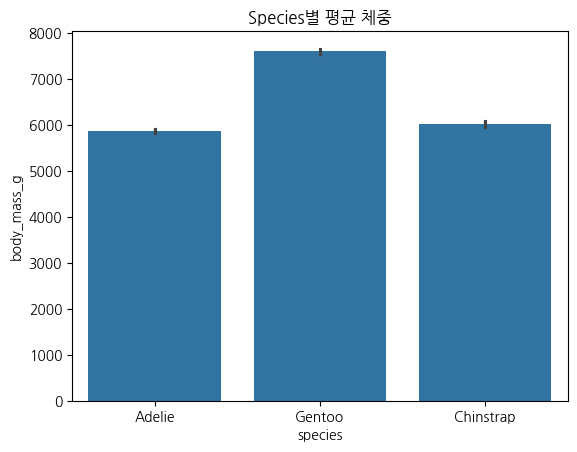

In [7]:
# 답안
sns.barplot(data=penguin_df, x='species', y='body_mass_g')
plt.xlabel('species')
plt.ylabel('body_mass_g')
plt.title('Species별 평균 체중')
plt.show()

4-2. species별 평균 체중을 계산하세요.

In [37]:
# 답안
penguin_df.groupby('species')['body_mass_g'].mean()

species
Adelie       5869.352657
Chinstrap    6026.172662
Gentoo       7606.344156
Name: body_mass_g, dtype: float64

4-3. 평균 체중이 가장 높은 종은 무엇인가요?

In [39]:
# 답안
species_mean = penguin_df.groupby('species')['body_mass_g'].mean()
species_mean.idxmax()

'Gentoo'

---
#### 문제 05
flipper_length_mm와 body_mass_g 사이의 관계를 확인하려 합니다.

5-1. 두 변수의 관계를 jointplot으로 시각화하세요.
- x축: flipper_length_mm, y축: body_mass_g
- kind='reg' 옵션을 사용하여 회귀선을 함께 표시하세요.

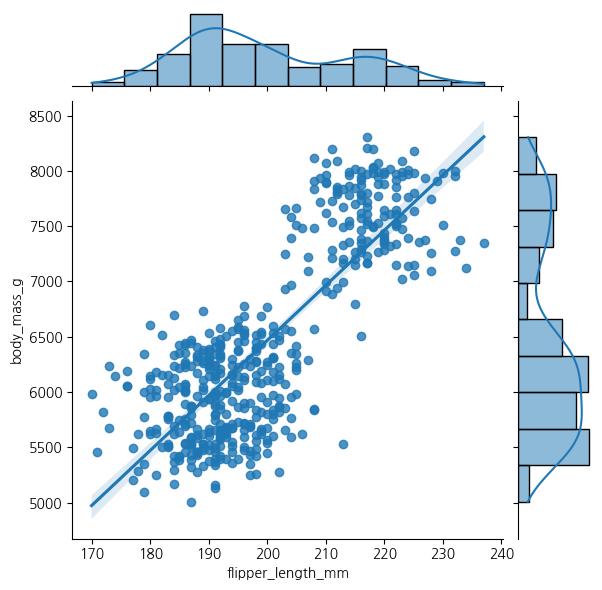

In [45]:
# 답안
sns.jointplot(data=penguin_df, x='flipper_length_mm', y='body_mass_g', kind='reg')

5-2. flipper_length_mm와 body_mass_g의 상관계수를 계산하세요.

In [11]:
#답안
# 상관계수가 뭔지 기억이 안나서 질문
penguin_df['flipper_length_mm'].corr(penguin_df['body_mass_g'])

np.float64(0.8046086170527548)

---
#### 문제 06
sex 컬럼의 결측치를 최빈값으로 처리하세요.

조건은 다음과 같습니다.

- sex 컬럼의 최빈값을 확인하세요.
- sex 컬럼의 결측치를 최빈값으로 대체하세요.
- 결측치 처리 후 전체 결측치 개수를 출력하세요.
- 다음 코드를 사용하세요

In [12]:
print('처리 전 결측치:', penguin_df['sex'].isnull().sum())

# 여기에 답안을 작성하세요.
print('최빈값:', penguin_df['sex'].fillna(penguin_df['sex'].mode())[0])

# 여기에 답안을 작성하세요.
print('처리 후 전체 결측치 수:', penguin_df.isnull().sum().sum())

처리 전 결측치: 25
최빈값: Male
처리 후 전체 결측치 수: 25


---
#### 문제 07
species, island, sex 컬럼을 원-핫 인코딩하세요.

조건은 다음과 같습니다.
- pd.get_dummies()를 사용하세요.
- 결과는 penguin_encoded 변수에 저장하세요.
- 다중공선성 방지를 위해 drop_first=True를 설정하세요.
- 인코딩 후 데이터의 컬럼 수를 출력하세요.
- 인코딩 후 데이터프레임의 상위 5개만 출력하세요.

In [13]:
# 답안
penguin_encoded = pd.get_dummies(data=penguin_df, columns=['species', 'island', 'sex'], drop_first=True)
penguin_encoded.shape[1]    # 9개

penguin_encoded.head(5)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species_Chinstrap,species_Gentoo,island_Dream,island_Torgersen,sex_Male
0,38.6,19.3,186,5759,False,False,True,False,True
1,47.8,13.7,215,7269,False,True,True,False,False
2,46.9,14.6,211,7282,False,True,False,False,False
3,50.1,17.8,199,5820,True,False,False,True,False
4,38.7,19.1,203,5659,False,False,True,False,False


---
#### 문제 08
body_mass_g를 예측하기 위해 피처 데이터와 타깃 데이터를 분리한 뒤, 훈련 데이터와 검증 데이터로 나누세요.
- 대상 데이터프레임: penguin_encoded

8-1. scikit-learn의 train_test_split를 import 하세요.

In [14]:
# 답안
from sklearn.model_selection import train_test_split

8-2. X와 y의 값을 저장하세요. body_mass_g를 y로(df.drop 사용), 나머지 컬럼을 X로 할당하세요.

In [15]:
# 답안
# X = ['species','island','bill_length_mm','bill_depth_mm','flipper_length_mm','sex']
# y = ['body_mass_g']

X = penguin_encoded.drop('body_mass_g', axis=1)
y = penguin_encoded['body_mass_g']

8-3. 훈련 데이터와 검증 데이터를 분리하세요.
- 검증 데이터 비율은 20%로 설정하세요.
- random_state=42
- 훈련 데이터와 검증 데이터의 크기를 출력하세요.

In [16]:
# 답안
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_valid.shape

((400, 8), (100, 8))

---
#### 문제 09
수치형·인코딩된 피처들의 스케일을 표준화하려 합니다.

9-1. StandardScaler를 생성하세요.

In [17]:
# 답안
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()

9-2. 훈련 데이터에는 fit_transform(), 검증 데이터에는 transform()을 적용하세요.

In [18]:
# 답안
X_train_scaled = std_scaler.fit_transform(X_train)
X_train_scaled
X_valid_scaled = std_scaler.transform(X_valid)
X_valid_scaled

array([[ 1.10062724,  0.87910694, -0.13277677,  1.62368828, -0.67812537,
         1.28413653, -0.5       , -1.        ],
       [ 0.26509241, -1.65651909,  0.93227756, -0.61588176,  1.47465358,
         1.28413653, -0.5       , -1.        ],
       [-1.27305124,  2.01204622, -1.62385284, -0.61588176, -0.67812537,
        -0.7787334 , -0.5       , -1.        ],
       [-0.55145298,  1.47255132, -1.1978311 , -0.61588176, -0.67812537,
        -0.7787334 , -0.5       , -1.        ],
       [ 1.40445808, -1.11702419,  1.21629205, -0.61588176,  1.47465358,
        -0.7787334 , -0.5       , -1.        ],
       [-1.84273407,  1.31070286, -0.41679126, -0.61588176, -0.67812537,
         1.28413653, -0.5       ,  1.        ],
       [-1.08315696, -0.41568082, -0.62980213, -0.61588176, -0.67812537,
         1.28413653, -0.5       , -1.        ],
       [-1.21608296,  0.0159151 , -0.2037804 , -0.61588176, -0.67812537,
         1.28413653, -0.5       , -1.        ],
       [-0.87427326,  0.93305643

9-3. 스케일링된 검증 데이터의 전체 최댓값을 반올림하여 출력하세요.

In [19]:
# 답안
X_valid_scaled.max().round(1)

np.float64(2.6)

---
#### 문제 10
펭귄 체중을 예측하기 위해 두 개의 회귀 모델을 학습하세요.

10-1. LinearRegression 모델을 학습하세요.
조건은 다음과 같습니다.
- 모델은 model_lr 변수에 저장하세요.
- 학습 데이터는 X_train_scaled, y_train을 사용하세요.

In [20]:
# 여기에 답안을 작성하세요.
# model에 변수를 한 번 더 저장할 필요 없음
from sklearn.linear_model import LinearRegression
model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)
print('LinearRegression 학습 완료')

LinearRegression 학습 완료


10-2. RandomForestRegressor 모델을 학습하세요.
조건은 다음과 같습니다.

- 모델은 model_rf 변수에 저장하세요.
- max_depth=5를 설정하세요.
- random_state=42를 설정하세요.
- 학습 데이터는 X_train_scaled, y_train을 사용하세요.

In [21]:
# 여기에 답안을 작성하세요.
from sklearn.ensemble import RandomForestRegressor
model_rf = RandomForestRegressor(
    max_depth=5,
    random_state=42
)
model_rf.fit(X_train_scaled, y_train)
print('RandomForestRegressor 학습 완료')

RandomForestRegressor 학습 완료


---
#### 문제 11
모델의 해석력을 이해하기 위해 RandomForest 모델의 특성 중요도를 파악하려 합니다.

11-1. 다음 가이드에 따라 특성 중요도를 파악하는데 에러가 나고 있습니다. 코드의 오류를 정정하세요.

1.  특성 중요도 점수와 변수 이름을 매핑하여 DataFrame 을 만드세요.
2.  중요도 점수를 기준으로 내림차순 정렬하고 상위 5개만 선정하세요.
3. 중요도 점수를 수평 막대 그래프( barplot )로 시각화하세요.



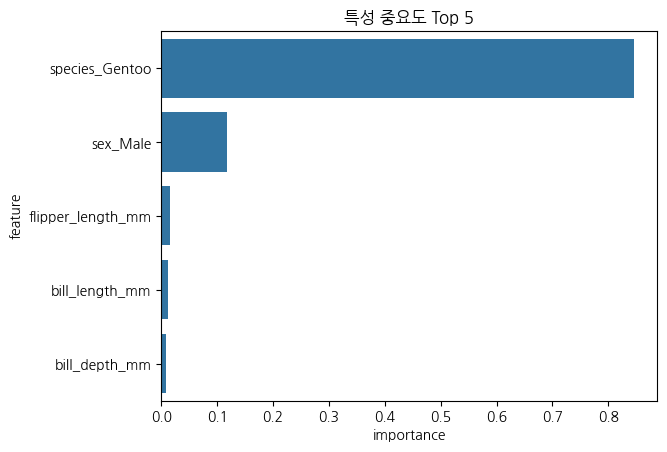

In [22]:
#(코드 셀) 다음 코드의 오류를 정정하고 실행하세요.

fi = pd.DataFrame({'feature': X.columns, 'importance': model_rf.feature_importances_})
fi = fi.sort_values('importance', ascending=False)[:5]
sns.barplot(x='importance', y='feature', data=fi)
plt.title('특성 중요도 Top 5')
plt.show( )

11-2. 출력된 그래프에서 가장 높은 중요도를 보이는 변수명을 작성하세요.

In [23]:
# 답안
# species_Gentoo
# 종 종류가 Gentoo이냐에 따라 체중 예측에 가장 큰 영향을 미침

---
#### 문제 12
앞서 학습한 LinearRegression과 RandomForestRegressor 모델의 성능을 비교하세요.

12-1. 두 모델의 MAE와 R² Score를 계산하세요.
조건은 다음과 같습니다.

- mean_absolute_error와 r2_score를 사용하세요.
- 검증 데이터 X_valid_scaled, y_valid를 사용하세요.
- 각 모델의 MAE와 R² Score를 출력하세요.

In [24]:
# 여기에 답안을 작성하세요.
from sklearn.metrics import mean_absolute_error , r2_score
pred_lr = model_lr.predict(X_valid_scaled)
pred_rf = model_rf.predict(X_valid_scaled)

lr_mae = mean_absolute_error(y_valid, pred_lr)
print(f'LinearRegression MAE: {lr_mae:.2f}')

lr_r2 = r2_score(y_valid, pred_lr)
print(f'LinearRegression R² : {lr_r2:.4f}')

rf_mae = mean_absolute_error(y_valid,pred_rf)
print(f'RandomForest MAE: {rf_mae:.2f}')

rf_r2 = r2_score(y_valid, pred_rf)
print(f'RandomForest R² : {rf_r2:.4f}')

LinearRegression MAE: 199.42
LinearRegression R² : 0.9093
RandomForest MAE: 195.99
RandomForest R² : 0.9094


12-2. 회귀 평가 지표 중 값이 1에 가까울수록 좋은 지표를 고르세요.
1. MAE
2. R² Score
3. Loss
4. Error

In [25]:
# 답안
# 2. R2 Score

---
#### 문제13
TensorFlow Keras를 사용하여 펭귄 체중을 예측하는 딥러닝 회귀 모델을 구성하세요.

13-1. Sequential 모델을 사용하세요.

조건은 다음과 같습니다.
- 첫 번째 은닉층은 Dense(64, activation='relu')로 구성하세요.
- 두 번째 은닉층은 Dense(32, activation='relu')로 구성하세요.
- 출력층은 Dense(1, activation='linear')로 구성하세요.
- 입력 특성 수는 X_train_scaled.shape[1]을 사용하세요.

In [30]:
# 케라스에서 층을 일직선으로 차례대로 쌓아 딥러닝 모델을 만드는 가장 단순하고 일반적인 구조
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# []로 레이어들을 리스트 형태로 Sequential로 전달
# 입력 특정 수 끝에 ,가 없으면 튜플이 아니라 숫자로 처리
# summary()로 값 확인 가능

# 여기에 답안을 작성하세요.
model_sq = Sequential([Dense(64,activation='relu', input_shape=(X_train_scaled.shape[1],)),
                      Dense(32,activation='relu'),
                      Dense(1,activation='linear')])

model_sq.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

13-2. EarlyStopping을 사용하세요.
- monitor='val_loss', patience=10, restore_best_weights=True로 설정하세요.
- estop 변수에 저장하세요.

In [32]:
# 검증 손실이 더 이상 개선되지 않을 때 사용 -> 학습을 중단시켜 과접합을 방지하고 학습 시간 단축
from tensorflow.keras.callbacks import EarlyStopping

# 여기에 답안을 작성하세요.
estop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

13-3. 모델 컴파일 단계에서 최적화 방법, 손실 함수, 평가 지표를 설정하세요.
- 최적화 알고리즘은 Adam, 손실 함수는 mse, 평가지표는 mae를 사용하세요.

In [35]:
# 답안
# metrics=['mae'] -> 여러 지표를 넣을 수 있기 때문에 리스트로 감싸야 함
model_sq.compile(optimizer='adam', loss='mse', metrics=['mae'])

13-4. 컴파일된 모델을 실제 데이터로 학습시키세요.
- 학습에 사용될 입력 데이터와정답은 X_train_scaled, y_train 입니다.
- 전체 학습 데이터를 최대 100번 반복 학습합니다.
- 한 번에 32개씩 데이터를 묶어서 가중치를 업데이트 합니다.
- 과적합 모니터링 용으로 매 epoch마다 검증 데이터로 성능을 평가합니다.
- EarlyStopping 콜백을 적용합니다.
- 학습 진행 상황을 출력하지 않습니다.
- 학습 결과는 history 변수에 저장하세요.

In [48]:
# 여기에 답안을 작성하세요.
history = model_sq.fit(X_train_scaled, y_train,
                      epochs=100,
                      batch_size=32,
                      validation_data= (X_valid_scaled, y_valid),
                      callbacks=[estop],
                      verbose=0)
                    
print('딥러닝 모델 학습 완료')

딥러닝 모델 학습 완료


---
#### 문제 14
앞서 학습한 딥러닝 모델의 학습 과정을 확인하려 합니다.

14-1. 학습 Loss와 검증 Loss를 하나의 그래프로 시각화하세요.
- title은 'Model Loss'라고 합니다.
- xlabel은 'Epoch', ylable은 'Loss'로 설정하세요.

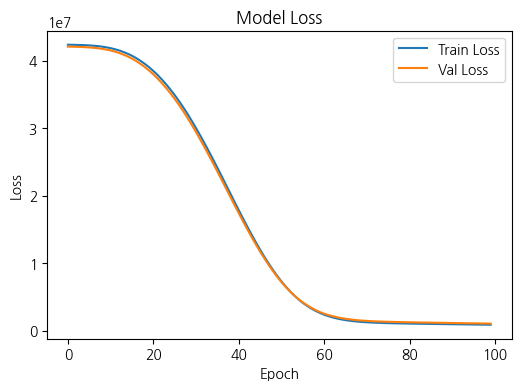

In [51]:
# 답안
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

14-2. 가장 낮은 검증 Loss와 해당 epoch를 출력하세요.

In [52]:
# 여기에 답안을 작성하세요.
best_val_loss = min(history.history['val_loss'])
best_epoch = history.history['val_loss'].index(best_val_loss) + 1

print('최저 검증 Loss:', round(best_val_loss, 4))
print('최저 검증 Loss epoch:', best_epoch)

최저 검증 Loss: 1030359.375
최저 검증 Loss epoch: 100


14-3. 딥러닝 모델의 검증 MAE를 평가하세요.

In [53]:
# 여기에 답안을 작성하세요.
dl_loss, dl_mae = model_sq.evaluate(X_valid_scaled, y_valid)
print('검증 Loss:', round(dl_loss, 4))
print('검증 MAE:', round(dl_mae, 4))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1030359.3750 - mae: 815.4951 
검증 Loss: 1030359.375
검증 MAE: 815.4951
